In [1]:
#pip install statsbombpy

In [2]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import warnings
from statsbombpy.api_client import NoAuthWarning
import io
import math
import time
import ast
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

In [3]:
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore', category=NoAuthWarning)

In [4]:
'''
#-----------------------------------------
#     MAKE API CALLS TO GET DATA
#-----------------------------------------

startTime = time.perf_counter()

# Get all competitions
competitions = sb.competitions()

# Filter for adult male competitions
adultMaleComps = competitions[(competitions['competition_youth'] == False) & (competitions['competition_gender'] == 'male')]

# Declare shots dataframe
allShots = pd.DataFrame()

# Loop through all competitions
for index, competition in adultMaleComps.iterrows():
    # Get all matches from the filtered competitions
    matches = sb.matches(competition_id = competition['competition_id'], season_id = competition['season_id'])
    # Loop through matches
    for matchID in matches['match_id']:
        # Get all events from match
        events = sb.events(match_id=matchID)
        # Filter events to just get shots
        shots = events[(events['type'] == 'Shot') & (events['shot_outcome'] != 'Blocked')]
        # Add shots to allShots dataframe
        allShots = pd.concat([allShots, shots])

print(allShots)
# Save data locally as a csv file
filePath = '/Users/jakeholfinger/Desktop/CC Analyst/Data/StatsBomb Shot Data.csv'
allShots.to_csv(filePath, index=False)

endTime = time.perf_counter()
executionTimeForGatheringData = endTime - startTime

print(f'Execution Time For Gathering Data: {executionTimeForGatheringData} seconds')
'''

"\n#-----------------------------------------\n#     MAKE API CALLS TO GET DATA\n#-----------------------------------------\n\nstartTime = time.perf_counter()\n\n# Get all competitions\ncompetitions = sb.competitions()\n\n# Filter for adult male competitions\nadultMaleComps = competitions[(competitions['competition_youth'] == False) & (competitions['competition_gender'] == 'male')]\n\n# Declare shots dataframe\nallShots = pd.DataFrame()\n\n# Loop through all competitions\nfor index, competition in adultMaleComps.iterrows():\n    # Get all matches from the filtered competitions\n    matches = sb.matches(competition_id = competition['competition_id'], season_id = competition['season_id'])\n    # Loop through matches\n    for matchID in matches['match_id']:\n        # Get all events from match\n        events = sb.events(match_id=matchID)\n        # Filter events to just get shots\n        shots = events[(events['type'] == 'Shot') & (events['shot_outcome'] != 'Blocked')]\n        # Add sh

In [5]:
def IsDefenderBetweenShooterAndGoal(shotData, defenderXCoord, defenderYCoord):
    '''Returns whether the defender is between the shooter and the goal'''
    
    # Define coordinates
    goalXCoord = shotData['goal_coordinates'][0]
    postOneYCoord = 44
    postTwoYCoord = 36
        
    shooterXCoord = shotData['location'][0]
    shooterYCoord = shotData['location'][1]

    # Check whether the shooter is on the goal line, then return false if it's true to prevent a division by zero
    if shooterXCoord == goalXCoord:
        return False

    # Calculate slopes from shooter to posts
    shooterToPostOneSlope = (shooterYCoord-postOneYCoord)/(shooterXCoord-goalXCoord)
    shooterToPostTwoSlope = (shooterYCoord-postTwoYCoord)/(shooterXCoord-goalXCoord)

    # Define the bounds that the y coordinate of the defender can be if they're between the shooter and goal
    postOneYBound = shooterToPostOneSlope * (defenderXCoord - shooterXCoord) + shooterYCoord
    postTwoYBound = shooterToPostTwoSlope * (defenderXCoord - shooterXCoord) + shooterYCoord

    # Determine whether the defender is between the shooter and the goal
    defenderIsBetweenShooterAndGoal = False
    if ((abs(defenderXCoord - goalXCoord) < abs(shooterXCoord - goalXCoord)) 
        and ((postOneYBound < defenderYCoord < postTwoYBound) or 
             (postOneYBound > defenderYCoord > postTwoYBound))):
        defenderIsBetweenShooterAndGoal = True
    
    return defenderIsBetweenShooterAndGoal

In [6]:
def ParseShotFreezeFrame(shotData):
    #Extract freeze frame data
    freezeFrame = shotData['shot_freeze_frame']

    # If the shot doesn't have a freeze frame, return an empty dictionary
    if not isinstance(freezeFrame, list):
        return {}, 0
    
    # Create freeze frame dict
    freezeFrameDict = {}
    numDefenders = 0
    # Loop throught every player in the freeze frame
    for player in freezeFrame:
        #If the player isn't the shooter's teammate
        if player['teammate'] == False:
            # Handle position being either a dict or string
            position = player['position']
            if isinstance(position, str):
                position = ast.literal_eval(position)
            positionName = position.get('name')
            
            # If the player is the opposition's goalkeeper
            if positionName == 'Goalkeeper':
                freezeFrameDict['gk_x_coord'] = player['location'][0]
                freezeFrameDict['gk_y_coord'] = player['location'][1]
            else:
                # Define defender coordinates
                defenderXCoord = player['location'][0]
                defenderYCoord = player['location'][1]
                if IsDefenderBetweenShooterAndGoal(shotData, defenderXCoord, defenderYCoord):
                    freezeFrameDict[f'defender_{numDefenders}_x_coord'] = defenderXCoord
                    freezeFrameDict[f'defender_{numDefenders}_y_coord'] = defenderYCoord
                    numDefenders += 1
                
    return freezeFrameDict, numDefenders

In [7]:
def CalcShotAngle(row):
    shooterX = row['location'][0]
    shooterY = row['location'][1]
    goalX = row['goal_coordinates'][0]
    post1Y = 36
    post2Y = 44
    
    # Vectors from shooter to each post
    vec1 = [goalX - shooterX, post1Y - shooterY]
    vec2 = [goalX - shooterX, post2Y - shooterY]
    
    # Dot product and magnitudes
    dotProduct = vec1[0]*vec2[0] + vec1[1]*vec2[1]
    mag1 = math.sqrt(vec1[0]**2 + vec1[1]**2)
    mag2 = math.sqrt(vec2[0]**2 + vec2[1]**2)
    
    # Angle between the two vectors
    return math.acos(dotProduct / (mag1 * mag2))

In [8]:
#-----------------------------------------
#    LOAD DATA AND INITIALLY CLEAN IT 
#-----------------------------------------

#Load data
filePath = '/Users/jakeholfinger/Desktop/CC Analyst/Data/StatsBomb Shot Data.csv'
allShots = pd.read_csv(filePath)
#allShots.head()

# Remove columns that don't have any data
for colName in allShots.columns:
    if allShots[colName].isna().all():
        allShots = allShots.drop(columns=[colName])

# Convert the columns' data that should be lists into lists (they're strings right now)
for col in ['location', 'shot_end_location', 'shot_freeze_frame']:
    allShots[col] = allShots[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

#-----------------------------------------
#  CREATE COLUMNS TO USE FOR REGRESSION
#-----------------------------------------

# Create center of goal location column
xValueMidfield = 60
allShots['goal_coordinates'] = allShots['shot_end_location'].apply(lambda loc: [0,40] if loc[0]<xValueMidfield else [120,40])

# Calculate shot distance
allShots['shot_distance'] = allShots.apply(lambda row: math.sqrt((row['goal_coordinates'][0] - row['location'][0])**2 +
                                                                 (row['goal_coordinates'][1] - row['location'][1])**2), axis=1)

# Calculate shot angle
allShots['shot_angle'] = allShots.apply(CalcShotAngle, axis=1)

# Separate shot freeze frame
parsedFreezeFrameDF = pd.DataFrame()
numDefendersList = []

for index, shot in allShots.iterrows():
    
    # Parse shot freeze frame
    parsedFreezeFrameDict, numDefenders = ParseShotFreezeFrame(shot)

    # Add any keys as a column that aren't already a column in the dataframe
    for key in parsedFreezeFrameDict:
        if not key in parsedFreezeFrameDF.columns:
            parsedFreezeFrameDF[key] = None
            
    # Add parsed shot freeze frame list to parsed shots freeze frame dataframe
    parsedFreezeFrameDF.loc[len(parsedFreezeFrameDF)] = parsedFreezeFrameDict
    
    # Add numDefenders
    numDefendersList.append(numDefenders)
    
# Add parsed freeze frame dataframe to allShots dataframe
allShots = pd.concat([allShots, parsedFreezeFrameDF], axis=1)

# Add number of defenders list to allShots dataframe as a column
allShots['num_defenders'] = numDefendersList

# Create a binary goal column
allShots['goal'] = allShots['shot_outcome'] == 'Goal'

# Add gk distance column
allShots['gk_distance'] = allShots.apply(lambda row: math.sqrt((row['gk_x_coord']-row['location'][0])**2 + 
                                                               (row['gk_y_coord']-row['location'][1])**2), axis=1)

# Add defender distance columns
for colName in allShots.columns:
    if 'defender' in colName and 'coord' in colName:
        defenderNum = colName[9]
        allShots[f'defender_{defenderNum}_distance'] = allShots.apply(lambda row: math.sqrt((row[f'defender_{defenderNum}_x_coord']-row['location'][0])**2 + 
                                                               (row[f'defender_{defenderNum}_y_coord']-row['location'][1])**2), axis=1)

# Split 'location' column into 'location_x' and 'location_y'
allShots['location_x'] = allShots['location'].apply(lambda loc: loc[0])
allShots['location_y'] = allShots['location'].apply(lambda loc: loc[1])

allShots.info()
#print(allShots)

/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/565394746.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  parsedFreezeFrameDF.loc[len(parsedFreezeFrameDF)] = parsedFreezeFrameDict
/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/565394746.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  parsedFreezeFrameDF.loc[len(parsedFreezeFrameDF)] = parsedFreezeFrameDict
/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/565394746.py:49: FutureWarning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55709 entries, 0 to 55708
Data columns (total 74 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   duration               55709 non-null  float64
 1   id                     55709 non-null  object 
 2   index                  55709 non-null  int64  
 3   location               55709 non-null  object 
 4   match_id               55709 non-null  int64  
 5   minute                 55709 non-null  int64  
 6   off_camera             77 non-null     object 
 7   out                    1362 non-null   object 
 8   period                 55709 non-null  int64  
 9   play_pattern           55709 non-null  object 
 10  player                 55709 non-null  object 
 11  player_id              55709 non-null  float64
 12  position               55709 non-null  object 
 13  possession             55709 non-null  int64  
 14  possession_team        55709 non-null  object 
 15  po

In [9]:
#-----------------------------------------
#          CLEAN DATA FURTHER
#-----------------------------------------

# Filter out shots that aren't wanted for regression (deflected, redirected, set pieces, and open goals)
allShotsRegression = allShots[(allShots['shot_deflected'].isna()) & (allShots['shot_redirect'].isna()) & (allShots['shot_type'] == 'Open Play') & (allShots['shot_open_goal'].isna())] 

# Fill empty values in 'shot_first_time' and 'shot_aerial_won' column with False
allShotsRegression['shot_first_time'] = allShotsRegression['shot_first_time'].fillna(False)
allShotsRegression['shot_aerial_won'] = allShotsRegression['shot_aerial_won'].fillna(False)
allShotsRegression['shot_one_on_one'] = allShotsRegression['shot_one_on_one'].fillna(False)
allShotsRegression['under_pressure'] = allShotsRegression['under_pressure'].fillna(False)
allShotsRegression['shot_follows_dribble'] = allShotsRegression['shot_follows_dribble'].fillna(False)
#allShotsRegression['shot_open_goal'] = allShotsRegression['shot_open_goal'].fillna(False)

# Drop rows with missing gk or defender distances
allShotsRegression = allShotsRegression.dropna(subset=['gk_distance'])
defenderMean = allShotsRegression[allShotsRegression['defender_0_distance'] < 35]['defender_0_distance'].mean()
allShotsRegression['defender_0_distance'] = allShotsRegression['defender_0_distance'].fillna(defenderMean)

#-----------------------------------------
#          LINEAR REGRESSION
#-----------------------------------------

# Reduce dataframe to only columns needed for linear regression
# location_x is included for depth model — closer shots force keepers further forward
# location_y is included for lateral model — keepers shift based on shooter's lateral position
allShotsLinearRegression = allShotsRegression[['shot_statsbomb_xg', 'shot_distance', 'shot_angle', 'defender_0_distance', 'num_defenders', 'location_x', 'location_y']]#, 'shot_open_goal']]

# Set up independent variables for depth model (no location_y since depth doesn't depend on lateral shooter position)
linearXAxisX = allShotsLinearRegression.drop('location_y', axis=1)
linearXAxisX = sm.add_constant(linearXAxisX)

# Set up independent variables for lateral model (includes location_y, excludes location_x)
linearXAxisY = allShotsLinearRegression.drop('location_x', axis=1)
linearXAxisY = sm.add_constant(linearXAxisY)

# Set up dependent variables
linearYAxisX = allShotsRegression['gk_x_coord']
linearYAxisY = allShotsRegression['gk_y_coord']

# Fit x model (gk depth)
linearXModel = OLS(linearYAxisX, linearXAxisX).fit()

# Fit y model (gk latitude)
linearYModel = OLS(linearYAxisY, linearXAxisY).fit()

#Print summaries
print("=== GK DEPTH (X) MODEL ===")
print(linearXModel.summary())
print()
print()
print("=== GK LATERAL (Y) MODEL ===")
print(linearYModel.summary())


=== GK DEPTH (X) MODEL ===
                            OLS Regression Results                            
Dep. Variable:             gk_x_coord   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     3410.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        17:46:54   Log-Likelihood:            -1.0473e+05
No. Observations:               50042   AIC:                         2.095e+05
Df Residuals:                   50035   BIC:                         2.095e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const  

/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/1268715731.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  allShotsRegression['shot_first_time'] = allShotsRegression['shot_first_time'].fillna(False)
/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/1268715731.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  allShotsRegression['shot_first_time'] = allShotsRegression['shot_first_time'].fillna(False)
/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/1268715731.py:10: FutureWarning

In [10]:
#-----------------------------------------
#         CALCULATE RESDIDUALS
#-----------------------------------------

# Calculate residuals - predicted position - actual position
allShotsRegression['residual_x'] = linearXModel.predict(linearXAxisX) - linearYAxisX
allShotsRegression['residual_y'] =  linearYAxisY - linearYModel.predict(linearXAxisY)

bounds = {}
for residual in ['residual_x', 'residual_y']:
    # Get mean and std of residual
    mean = allShotsRegression[residual].mean()
    std = allShotsRegression[residual].std()
    bounds[residual] = (mean - 3*std, mean + 3*std)
    
# Apply both filters
allShotsRegression = allShotsRegression[
    (allShotsRegression['residual_x'] > bounds['residual_x'][0]) & 
    (allShotsRegression['residual_x'] < bounds['residual_x'][1]) &
    (allShotsRegression['residual_y'] > bounds['residual_y'][0]) & 
    (allShotsRegression['residual_y'] < bounds['residual_y'][1])
]

# Take absolute value of residual_y because direction doesn't matter
allShotsRegression['residual_y'] = allShotsRegression['residual_y'].abs()

#-----------------------------------------
#    CLEAN DATA FOR LOGISTIC REGRESSION
#-----------------------------------------

# Reduce dataframe to only columns needed for regression
allShotsRegression = allShotsRegression[['goal', 'shot_aerial_won', 'shot_body_part', 'shot_first_time', 'shot_technique', 'shot_one_on_one', 'shot_distance', 'shot_angle', 'shot_follows_dribble', 'under_pressure', 'residual_x', 'residual_y', 'defender_0_distance', 'num_defenders']]#, 'play_pattern, 'shot_open_goal']]

# Convert categorical columns into numerical columns
allShotsRegressionDummies = pd.get_dummies(allShotsRegression, columns=['shot_aerial_won', 'shot_body_part', 'shot_first_time', 'shot_technique', 'shot_one_on_one', 'shot_follows_dribble', 'under_pressure'], dtype=int, drop_first=True)#, 'shot_open_goal'], dtype=int, drop_first=True)

allShotsRegressionDummies.info()

# Add quadratic depth term
allShotsRegressionDummies['residual_x_squared'] = allShotsRegressionDummies['residual_x'] ** 2

# Add interaction terms to allow optimal residual to vary by shot context
allShotsRegressionDummies['residual_x_x_distance'] = allShotsRegressionDummies['residual_x'] * allShotsRegressionDummies['shot_distance']
allShotsRegressionDummies['residual_x_squared_x_distance'] = allShotsRegressionDummies['residual_x_squared'] * allShotsRegressionDummies['shot_distance']

#-----------------------------------------
#    COMPLETE LOGISTIC REGRESSION
#-----------------------------------------

# Define axes
dependentVar = allShotsRegressionDummies['goal']
independentVars = allShotsRegressionDummies.drop(columns=['goal'])

# Add constant
independentVars = sm.add_constant(independentVars)

# Fit logistic regression
model = sm.Logit(dependentVar, independentVars)
result = model.fit()

print(result.summary())

print(allShotsRegression['residual_y'].describe())


<class 'pandas.core.frame.DataFrame'>
Index: 48575 entries, 0 to 55708
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   goal                          48575 non-null  bool   
 1   shot_distance                 48575 non-null  float64
 2   shot_angle                    48575 non-null  float64
 3   residual_x                    48575 non-null  float64
 4   residual_y                    48575 non-null  float64
 5   defender_0_distance           48575 non-null  float64
 6   num_defenders                 48575 non-null  int64  
 7   shot_aerial_won_True          48575 non-null  int64  
 8   shot_body_part_Left Foot      48575 non-null  int64  
 9   shot_body_part_Other          48575 non-null  int64  
 10  shot_body_part_Right Foot     48575 non-null  int64  
 11  shot_first_time_True          48575 non-null  int64  
 12  shot_technique_Diving Header  48575 non-null  int64  
 13  shot_t

Optimal residual_x at mean distance (18.5m): -1.712m
Values (means) used for charts/values: {'shot_distance': 18.496480618885485, 'shot_angle': 0.454007882762239, 'residual_x': 0, 'residual_y': 0, 'defender_0_distance': 7.0625840871647725, 'num_defenders': 0.5310962429233145, 'shot_aerial_won_True': 0, 'shot_body_part_Left Foot': 0, 'shot_body_part_Other': 0, 'shot_body_part_Right Foot': 1, 'shot_first_time_True': 0, 'shot_technique_Diving Header': 0, 'shot_technique_Half Volley': 0, 'shot_technique_Lob': 0, 'shot_technique_Normal': 1, 'shot_technique_Overhead Kick': 0, 'shot_technique_Volley': 0, 'shot_one_on_one_True': 0, 'shot_follows_dribble_True': 0, 'under_pressure_True': 0, 'residual_x_squared': 0, 'residual_x_x_distance': 0, 'residual_x_squared_x_distance': 0}


/var/folders/b5/v202j161071bmzj3nfjn1k6h0000gn/T/ipykernel_85993/3154457303.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{-t:.1f}' for t in ticks])


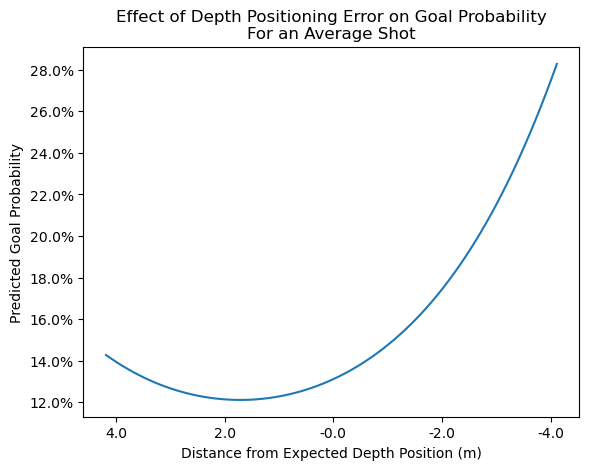

Values (means) used for charts/values: {'shot_distance': 18.496480618885485, 'shot_angle': 0.454007882762239, 'residual_x': 0, 'residual_y': 0, 'defender_0_distance': 7.0625840871647725, 'num_defenders': 0.5310962429233145, 'shot_aerial_won_True': 0, 'shot_body_part_Left Foot': 0, 'shot_body_part_Other': 0, 'shot_body_part_Right Foot': 1, 'shot_first_time_True': 0, 'shot_technique_Diving Header': 0, 'shot_technique_Half Volley': 0, 'shot_technique_Lob': 0, 'shot_technique_Normal': 1, 'shot_technique_Overhead Kick': 0, 'shot_technique_Volley': 0, 'shot_one_on_one_True': 0, 'shot_follows_dribble_True': 0, 'under_pressure_True': 0, 'residual_x_squared': 0, 'residual_x_x_distance': 0, 'residual_x_squared_x_distance': 0}


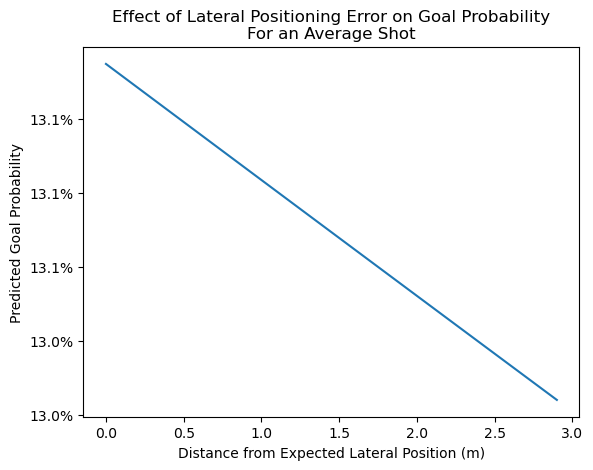

In [11]:
from matplotlib.ticker import FuncFormatter
#-----------------------------------------------------
#   SET UP DATA FOR PLOT THAT ISOLATES GK DISTANCE
#-----------------------------------------------------

# Create dictionary for storing means (if its a numerical column) and most common values (it it was categorical)
meanCommonDict = {}
for colName in allShotsRegressionDummies.columns:
    col = allShotsRegressionDummies[colName]
    if colName in ['shot_distance', 'shot_angle', 'residual_x', 'residual_y', 'defender_0_distance', 'num_defenders']:
        meanCommonDict[colName] = allShotsRegressionDummies[colName].mean()
    elif colName != 'goal':
        meanCommonDict[colName] = allShotsRegressionDummies[colName].mode()[0]
meanCommonDict['shot_body_part_Right Foot'] = 1

# Calculate beta coefficients for optimal residual formula
# optimal_residual_x = -(beta1 + beta3 * distance) / (2 * (beta2 + beta4 * distance))
beta1 = result.params['residual_x']
beta2 = result.params['residual_x_squared']
beta3 = result.params['residual_x_x_distance']
beta4 = result.params['residual_x_squared_x_distance']

# Optimal residual at mean shot distance for reference
mean_distance = allShotsRegressionDummies['shot_distance'].mean()
optimalResidualX_mean = -(beta1 + beta3 * mean_distance) / (2 * (beta2 + beta4 * mean_distance))
print(f'Optimal residual_x at mean distance ({mean_distance:.1f}m): {optimalResidualX_mean:.3f}m')

residuals = ['residual_x', 'residual_y']
residualNameDict = {'residual_x': 'Depth', 'residual_y': 'Lateral'}
for residual in residuals:
    # Reset residuals to zero
    meanCommonDict['residual_x'] = 0
    meanCommonDict['residual_y'] = 0
    meanCommonDict['residual_x_squared'] = 0
    meanCommonDict['residual_x_x_distance'] = 0
    meanCommonDict['residual_x_squared_x_distance'] = 0

    print(f'Values (means) used for charts/values: {meanCommonDict}')

    # Clip to ±3 standard deviations
    std = allShotsRegressionDummies[residual].std()
    minCoord = max(allShotsRegressionDummies[residual].min(), -3 * std)
    maxCoord = min(allShotsRegressionDummies[residual].max(), 3 * std)
    
    # Create a synthetic dataframe of shots for each residual value
    syntheticDF = pd.DataFrame(columns=meanCommonDict.keys())
    for coord in np.arange(minCoord, maxCoord, 0.1):
        meanCommonDict[residual] = coord
        if residual == 'residual_x':
            meanCommonDict['residual_x_squared'] = coord ** 2
            meanCommonDict['residual_x_x_distance'] = coord * meanCommonDict['shot_distance']
            meanCommonDict['residual_x_squared_x_distance'] = coord ** 2 * meanCommonDict['shot_distance']
        syntheticDF.loc[len(syntheticDF)] = meanCommonDict

    #-----------------------------------------------------
    #      RUN DATAFRAME THROUGH THE FITTED MODEL
    #-----------------------------------------------------
    
    # Add constant to synthetic dataframe
    syntheticDFConst = sm.add_constant(syntheticDF, has_constant='add')

    # Generate predicted probabilities
    predictedProbabilities = result.predict(syntheticDFConst)
    
    # Add goal probabilities to synthetic dataframe
    syntheticDF['predicted_goal_probability'] = predictedProbabilities
    
    #-----------------------------------------------------
    #                   PLOT RESULTS
    #-----------------------------------------------------
    # Define x and y axes
    xAxis = syntheticDF[residual]
    yAxis = syntheticDF['predicted_goal_probability'] * 100
    
    # Create residual plot
    plt.plot(xAxis, yAxis)

    # Format y-axis ticks as percentages
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}%'))
    
    # Add labels to plot
    plt.xlabel(f'Distance from Expected {residualNameDict[residual]} Position (m)')
    plt.ylabel('Predicted Goal Probability')
    plt.title(f'Effect of {residualNameDict[residual]} Positioning Error on Goal Probability\nFor an Average Shot')

    if residual == 'residual_x':
        ax = plt.gca()
        ticks = ax.get_xticks()
        ax.set_xticklabels([f'{-t:.1f}' for t in ticks])
    
    # Show plot
    plt.show()


In [14]:
def get_optimal_goalkeeper_position():
    """
    Prompts user for shot context and returns the optimal goalkeeper position
    based on the fitted regression models.
    """
    
    print("=" * 60)
    print("  OPTIMAL GOALKEEPER POSITIONING CALCULATOR")
    print("=" * 60)
    print("\nEnter the shot context below.")
    print("StatsBomb coordinates: pitch is 120 x 80")
    print("Goal center is at (120, 40). Shots attack toward x=120.\n")
    
    #--------------------------------------------------
    # COLLECT SHOOTER POSITION
    #--------------------------------------------------
    print("--- SHOOTER POSITION ---")
    shooter_x = float(input("Shooter x-coordinate (e.g. 105 = inside box, 115 = very close): "))
    shooter_y = float(input("Shooter y-coordinate (e.g. 40 = central, 25 = left wing, 55 = right wing): "))
    
    #--------------------------------------------------
    # COLLECT DEFENDER INFO
    #--------------------------------------------------
    print("\n--- DEFENDERS (between shooter and goal) ---")
    num_defenders = int(input("Number of defenders between shooter and goal (0, 1, 2, etc.): "))
    
    if num_defenders > 0:
        print("Enter the position of the closest defender to the shooter:")
        def_x = float(input("  Defender x-coordinate: "))
        def_y = float(input("  Defender y-coordinate: "))
        defender_0_distance = math.sqrt((def_x - shooter_x)**2 + (def_y - shooter_y)**2)
        print(f"  → Calculated defender distance: {defender_0_distance:.2f}m")
    else:
        defender_0_distance = defenderMean
        print(f"  → No defenders — using dataset mean: {defender_0_distance:.2f}m")
    
    #--------------------------------------------------
    # OPTIONAL: xG VALUE
    #--------------------------------------------------
    print("\n--- OPTIONAL ---")
    xg_input = input(f"StatsBomb xG value (press Enter to use dataset mean "
                     f"{allShotsLinearRegression['shot_statsbomb_xg'].mean():.3f}): ")
    shot_xg = float(xg_input) if xg_input.strip() else allShotsLinearRegression['shot_statsbomb_xg'].mean()
    
    #--------------------------------------------------
    # CALCULATE DERIVED VARIABLES
    #--------------------------------------------------
    
    # Shot distance from goal center
    shot_distance = math.sqrt((120 - shooter_x)**2 + (40 - shooter_y)**2)
    
    # Shot angle (angle subtended by goalposts from shooter position)
    vec1 = [120 - shooter_x, 36 - shooter_y]
    vec2 = [120 - shooter_x, 44 - shooter_y]
    dot  = vec1[0]*vec2[0] + vec1[1]*vec2[1]
    mag1 = math.sqrt(vec1[0]**2 + vec1[1]**2)
    mag2 = math.sqrt(vec2[0]**2 + vec2[1]**2)
    shot_angle = math.acos(max(-1, min(1, dot / (mag1 * mag2))))
    
    print(f"\n  → Shot distance: {shot_distance:.2f}m")
    print(f"  → Shot angle:    {math.degrees(shot_angle):.1f}°")
    
    #--------------------------------------------------
    # PREDICT EXPECTED GK POSITION (linear models)
    #--------------------------------------------------
    
    depth_context = pd.DataFrame([{
        'const':                1,
        'shot_distance':        shot_distance,
        'shot_angle':           shot_angle,
        'defender_0_distance':  defender_0_distance,
        'num_defenders':        num_defenders,
        'location_x':           shooter_x
    }])
    
    lateral_context = pd.DataFrame([{
        'const':                1,
        'shot_statsbomb_xg':    shot_xg,
        'shot_distance':        shot_distance,
        'shot_angle':           shot_angle,
        'defender_0_distance':  defender_0_distance,
        'num_defenders':        num_defenders,
        'location_y':           shooter_y
    }])
    
    expected_gk_x = linearXModel_noXG.predict(depth_context)[0]
    expected_gk_y = linearYModel.predict(lateral_context)[0]
    
    #--------------------------------------------------
    # CALCULATE OPTIMAL DEPTH
    # residual_x = predicted - actual
    # optimal residual = -(β1 + β3*distance) / (2*(β2 + β4*distance))
    # optimal actual   = predicted - optimal_residual
    #--------------------------------------------------
    
    b1 = result.params['residual_x']
    b2 = result.params['residual_x_squared']
    b3 = result.params['residual_x_x_distance']
    b4 = result.params['residual_x_squared_x_distance']
    
    optimal_residual = -(b1 + b3 * shot_distance) / (2 * (b2 + b4 * shot_distance))
    optimal_gk_x     = expected_gk_x - optimal_residual
    optimal_gk_x     = min(optimal_gk_x, 120.0)  # can't stand inside the goal
    
    # Optimal lateral = expected lateral
    # residual_y is insignificant, so zero lateral deviation is optimal
    optimal_gk_y = expected_gk_y
    
    # Convert to intuitive units
    optimal_depth_from_goal  = 120 - optimal_gk_x
    average_depth_from_goal  = 120 - expected_gk_x
    lateral_from_center      = optimal_gk_y - 40
    depth_adjustment         = optimal_depth_from_goal - average_depth_from_goal
    
    #--------------------------------------------------
    # PRINT RESULTS
    #--------------------------------------------------
    
    print("\n" + "=" * 60)
    print("  RESULTS")
    print("=" * 60)
    
    print(f"\n  Shot context:")
    print(f"    Shooter:      ({shooter_x:.1f}, {shooter_y:.1f})")
    print(f"    Distance:     {shot_distance:.1f}m from goal")
    print(f"    Angle:        {math.degrees(shot_angle):.1f}°")
    print(f"    Defenders:    {num_defenders}")
    
    print(f"\n  OPTIMAL GOALKEEPER POSITION:")
    print(f"    Depth:    {optimal_depth_from_goal:.2f}m off the goal line")
    
    if abs(lateral_from_center) < 0.1:
        print(f"    Lateral:  centered on goal")
    elif lateral_from_center > 0:
        print(f"    Lateral:  {lateral_from_center:.2f}m toward top of pitch (y > 40)")
    else:
        print(f"    Lateral:  {abs(lateral_from_center):.2f}m toward bottom of pitch (y < 40)")
    
    print(f"\n  Context:")
    print(f"    Average keeper depth in this situation: {average_depth_from_goal:.2f}m")
    
    if depth_adjustment > 0.1:
        print(f"    → Should be {depth_adjustment:.2f}m DEEPER than the typical keeper here")
    elif depth_adjustment < -0.1:
        print(f"    → Should be {abs(depth_adjustment):.2f}m MORE AGGRESSIVE than the typical keeper here")
    else:
        print(f"    → Typical positioning is close to optimal here")
    
    print(f"\n  StatsBomb coordinates: x = {optimal_gk_x:.2f},  y = {optimal_gk_y:.2f}")
    print("=" * 60)
    
    return {
        'optimal_gk_x':            round(optimal_gk_x, 2),
        'optimal_gk_y':            round(optimal_gk_y, 2),
        'optimal_depth_from_goal': round(optimal_depth_from_goal, 2),
        'lateral_from_center':     round(lateral_from_center, 2),
        'average_depth_from_goal': round(average_depth_from_goal, 2),
        'depth_adjustment':        round(depth_adjustment, 2),
        'shot_distance':           round(shot_distance, 2),
        'shot_angle_degrees':      round(math.degrees(shot_angle), 1)
    }


# Run the calculator
position = get_optimal_goalkeeper_position()

  OPTIMAL GOALKEEPER POSITIONING CALCULATOR

Enter the shot context below.
StatsBomb coordinates: pitch is 120 x 80
Goal center is at (120, 40). Shots attack toward x=120.

--- SHOOTER POSITION ---

--- DEFENDERS (between shooter and goal) ---
Enter the position of the closest defender to the shooter:


ValueError: could not convert string to float: ''

In [ ]:
#--------------------------
#  POSSIBLE IMPROVEMENTS
#--------------------------
# - Include goalkeeper height (more control)
# - Include play pattern (more control)
# - Include open goals (could possibly make lateral positioning significant)
# - Include player position (more control - maybe defenders usually take closer shots)
# - Include number of attackers in attacking area
# - Factor in more locations of defenders and attackers